In [3]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,AIMessage
import operator

In [23]:
class ChatState(TypedDict):
    history:Annotated[list[str],operator.add]
    user_input:str
    clarification_question:str
    clarification_answer:str
    clarification:bool=Field(description="Clarification require check")
    answer:str

In [24]:
class ClarificationSchema(BaseModel):
    clarification_question:str=Field(description="Clarification asked from llm")
    clarification:bool=Field(description="Clarification require check")

In [25]:
load_dotenv()
model=ChatGroq(model="llama-3.3-70b-versatile")

In [26]:
clarification_model=model.with_structured_output(ClarificationSchema)

In [36]:
def user_input(state:ChatState):
    user=input()
    return {'user_input':user,"history":[HumanMessage(user)]}

In [ ]:
def clarification_llm(state:ChatState):
    prompt = f"""
You are a decision-making AI responsible for determining whether a user's query is clear enough to answer.

Your task:
1. Analyze the user's query
2. Decide if it can be answered directly

---

A query is CLEAR if:
- A reasonable and helpful answer can be given
- Even if it is broad, a general overview would still be useful

A query is UNCLEAR only if:
- The intent is impossible to understand
- Multiple completely different interpretations exist
- Answering directly would likely be wrong or misleading

IMPORTANT:
- Broad queries like "AI", "India", "Maurya Empire" are CLEAR
- Do NOT ask follow-up questions repeatedly

---

If the query is CLEAR:
Return ONLY:
{{
  "clarification": true,
  "clarification_question": ""
}}

If the query is UNCLEAR:
- Ask exactly ONE specific clarification question
- Do NOT ask multiple questions
- Do NOT answer the original query

Return ONLY:
{{
  "clarification": false,
  "clarification_question": "<your question>"
}}

---

Rules:
- Never answer the user's query
- Never explain your reasoning
- Output must be valid JSON only
- Do not introduce new keys

---

User Query:
"{state['user_input']}"
"""
    res=clarification_model.invoke(prompt)
    return {'clarification':res.clarification,'clarification_question':res.clarification_question,"history":[AIMessage(res.clarification_question)]}

In [46]:
def route_clarification(state:ChatState):
    if(state['clarification']==True):
        return "clear"
    return "need_clarification"

In [47]:
def clarify(state:ChatState):
    print(state['clarification_question'])
    user=input()
    return {"clarification_answer":user,"history":[HumanMessage(user)]}

In [48]:
def update_question(state:ChatState):
    prompt=f""""
    You are an AI that refines user queries.

Your task:
- Combine the original query and the clarification answer
- Use conversation history ONLY if needed to preserve context
- Produce a single clear and complete query

---

Original Query:
{state['user_input']}

Clarification Question:
{state['clarification_question']}

User's Clarification Answer:
{state['clarification_answer']}

Conversation History (may help for context, ignore if not needed):
{state['history']}

---

Rules:
- Keep the original intent intact
- Incorporate the clarification answer correctly
- Use history only if it adds missing context
- Do NOT repeat the history
- Do NOT ask a question
- Do NOT generate explanations
- Keep it concise and clear (one sentence)

---

Output:
Only return the refined query as plain text."""
    res=model.invoke(prompt).content
    return{"user_input":res, "clarification":True,"clarification_question":"","clarification_answer":""}

In [53]:
def generate_ans(state:ChatState):
    prompt = f"""
You are a helpful AI assistant.

Answer the user's query clearly and concisely.

---

User Query:
{state['user_input']}

---

Rules:
- Keep the answer short (2-3 paragraph max.)
- Use simple and easy-to-understand language
- Be direct and relevant
- Do not ask follow-up questions
- Do not add unnecessary details
- If the query is broad, give a brief general overview

---

Answer:
"""
    res=model.invoke(prompt).content

    return {"answer":res,"history":[AIMessage(res)]}

In [54]:
state=StateGraph(ChatState)

# nodes
state.add_node("user_input",user_input)
state.add_node("clarification_llm",clarification_llm)
state.add_node("clarify",clarify)
state.add_node("generate_ans",generate_ans)
state.add_node("update_question",update_question)
# edges
state.add_edge(START,"user_input")

state.add_edge("user_input","clarification_llm")
state.add_conditional_edges("clarification_llm",route_clarification,{"clear":"generate_ans","need_clarification":"clarify"})
state.add_edge("update_question","clarification_llm")
state.add_edge("clarify","update_question")
state.add_edge("generate_ans",END)


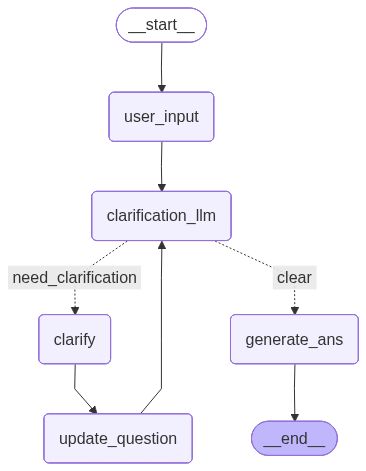

In [55]:
workflow=state.compile()
workflow

In [56]:
workflow.invoke({})

What kind of story would you like me to generate?
What kind of horror story are you looking for, e.g. supernatural, psychological, or slasher?


{'history': [HumanMessage(content='generate a story', additional_kwargs={}, response_metadata={}),
  AIMessage(content='What kind of story would you like me to generate?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='horror story', additional_kwargs={}, response_metadata={}),
  AIMessage(content='What kind of horror story are you looking for, e.g. supernatural, psychological, or slasher?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='psychological', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='In the small town of Ravenswood, a mysterious figure known as "The Whisperer" began to appear in people\'s dreams. At first, the dreams were harmless, but soon they turned into terrifying nightmares. The Whisperer would whisper a single phrase in th